In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score, precision_score, recall_score
)
 
# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [23]:
print("=" * 70)
print("STEP 1: LOADING AND CLEANING DATA")
print("=" * 70)
 
df = pd.read_csv('/kaggle/input/datasets/colabsss/legacy-industrial-equipment-sensor-logs/industrial_dataset.csv')
 
print(f"\nOriginal Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
 
# Drop redundant columns
df.drop(columns=['Timestamp', 'Operator_Notes'], inplace=True, errors='ignore')
 
# Drop rows with missing target
df.dropna(subset=['Target'], inplace=True)
 
# Encode Target
le_target = LabelEncoder()
df['Target_Encoded'] = le_target.fit_transform(df['Target'])  # Normal=1, Fault=0 (alphabetical)
 
print(f"\nAfter dropping Timestamp & Operator_Notes → Shape: {df.shape}")
print(f"\nTarget distribution:\n{df['Target'].value_counts()}")
print(f"\nTarget encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

STEP 1: LOADING AND CLEANING DATA

Original Shape: (2500, 17)

Columns: ['Timestamp', 'Machine_ID', 'Temperature_C', 'Pressure_bar', 'Vibration_Level', 'Voltage_V', 'Current_A', 'Sound_dB', 'FlowRate_Lmin', 'Humidity_%', 'Oil_Quality_Index', 'Energy_Consumption_kWh', 'Production_Rate', 'Load_Percentage', 'Operator_Notes', 'Error_Message', 'Target']

After dropping Timestamp & Operator_Notes → Shape: (2500, 16)

Target distribution:
Target
Normal    1861
Fault      639
Name: count, dtype: int64

Target encoding: {'Fault': np.int64(0), 'Normal': np.int64(1)}


In [24]:
print("\n" + "=" * 70)
print("STEP 2: NORMAL OPERATING RANGES PER MACHINE")
print("=" * 70)
 
# Sort by Machine_ID
df.sort_values(by='Machine_ID', inplace=True)
df.reset_index(drop=True, inplace=True)
 
# Input features (all except Machine_ID, Target, Target_Encoded, Error_Message)
sensor_cols = [
    'Temperature_C', 'Pressure_bar', 'Vibration_Level', 'Voltage_V',
    'Current_A', 'Sound_dB', 'FlowRate_Lmin', 'Humidity_%',
    'Oil_Quality_Index', 'Energy_Consumption_kWh', 'Production_Rate',
    'Load_Percentage'
]
 
# Filter existing columns only
sensor_cols = [c for c in sensor_cols if c in df.columns]
 
# Compute normal operating ranges (only rows where Target == 'Normal')
normal_df = df[df['Target'] == 'Normal']
machine_ids = sorted(df['Machine_ID'].unique())
 
normal_ranges = {}
for mid in machine_ids:
    mdf = normal_df[normal_df['Machine_ID'] == mid][sensor_cols]
    normal_ranges[mid] = {
        col: (mdf[col].min(), mdf[col].max()) for col in sensor_cols
    }
 
# Print normal ranges
for mid in machine_ids[:3]:  # Print first 3 for brevity
    print(f"\n--- Machine: {mid} | Normal Operating Ranges ---")
    for col, (lo, hi) in normal_ranges[mid].items():
        print(f"  {col:<28} : [{lo:.2f}, {hi:.2f}]")


STEP 2: NORMAL OPERATING RANGES PER MACHINE

--- Machine: 1 | Normal Operating Ranges ---
  Temperature_C                : [43.39, 87.66]
  Pressure_bar                 : [1.96, 4.89]
  Vibration_Level              : [0.03, 1.77]
  Voltage_V                    : [208.90, 236.70]
  Current_A                    : [2.57, 8.53]
  Sound_dB                     : [39.90, 94.30]
  FlowRate_Lmin                : [5.96, 19.49]
  Humidity_%                   : [33.90, 73.00]
  Oil_Quality_Index            : [0.58, 1.24]
  Energy_Consumption_kWh       : [0.50, 2.66]
  Production_Rate              : [25.04, 56.06]
  Load_Percentage              : [40.00, 99.00]

--- Machine: 2 | Normal Operating Ranges ---
  Temperature_C                : [49.10, 87.44]
  Pressure_bar                 : [1.72, 5.07]
  Vibration_Level              : [-0.16, 1.76]
  Voltage_V                    : [203.20, 234.10]
  Current_A                    : [3.12, 8.20]
  Sound_dB                     : [38.50, 95.30]
  FlowRate_

In [25]:
print("\n" + "=" * 70)
print("STEP 3: FEATURE PREPARATION")
print("=" * 70)
 
# Encode Machine_ID
le_machine = LabelEncoder()
df['Machine_ID_Enc'] = le_machine.fit_transform(df['Machine_ID'])
 
# Encode Error_Message if present
if 'Error_Message' in df.columns:
    df['Error_Message_Enc'] = LabelEncoder().fit_transform(df['Error_Message'].astype(str))
    feature_cols = sensor_cols + ['Machine_ID_Enc', 'Error_Message_Enc']
else:
    feature_cols = sensor_cols + ['Machine_ID_Enc']
 
X = df[feature_cols].copy()
y = df['Target_Encoded'].copy()
 
# Handle NaNs
X.fillna(X.median(), inplace=True)
 
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features used    : {feature_cols}")


STEP 3: FEATURE PREPARATION
Training samples : 2000
Test samples     : 500
Features used    : ['Temperature_C', 'Pressure_bar', 'Vibration_Level', 'Voltage_V', 'Current_A', 'Sound_dB', 'FlowRate_Lmin', 'Humidity_%', 'Oil_Quality_Index', 'Energy_Consumption_kWh', 'Production_Rate', 'Load_Percentage', 'Machine_ID_Enc', 'Error_Message_Enc']


In [26]:
print("\n" + "=" * 70)
print("STEP 4: TRAINING ALL CLASSIFIER MODELS")
print("=" * 70)
 
models = {
    "Logistic Regression"       : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"             : DecisionTreeClassifier(random_state=42),
    "Random Forest"             : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"         : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "AdaBoost"                  : AdaBoostClassifier(n_estimators=100, random_state=42),
    "Extra Trees"               : ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Bagging"                   : BaggingClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)"                 : SVC(kernel='rbf', probability=True, random_state=42),
    "KNN"                       : KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes"               : GaussianNB(),
    "LDA"                       : LinearDiscriminantAnalysis(),
    "QDA"                       : QuadraticDiscriminantAnalysis(),
    "XGBoost"                   : XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM"                  : LGBMClassifier(random_state=42, verbose=-1),
}
 
trained_models = {}
model_metrics = {}
 
for name, model in models.items():
    print(f"  Training: {name} ...", end=" ")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
 
    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    auc   = roc_auc_score(y_test, y_prob) if y_prob is not None else None
 
    model_metrics[name] = {
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1 Score' : f1,
        'ROC-AUC'  : auc,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }
    trained_models[name] = model
    auc_str = f"{auc:.3f}" if auc is not None else "N/A"
    print(f" Acc={acc:.3f} | F1={f1:.3f} | AUC={auc_str}")


STEP 4: TRAINING ALL CLASSIFIER MODELS
  Training: Logistic Regression ...  Acc=0.744 | F1=0.853 | AUC=0.493
  Training: Decision Tree ...  Acc=0.602 | F1=0.727 | AUC=0.497
  Training: Random Forest ...  Acc=0.738 | F1=0.849 | AUC=0.461
  Training: Gradient Boosting ...  Acc=0.734 | F1=0.846 | AUC=0.500
  Training: AdaBoost ...  Acc=0.744 | F1=0.853 | AUC=0.513
  Training: Extra Trees ...  Acc=0.742 | F1=0.852 | AUC=0.459
  Training: Bagging ...  Acc=0.730 | F1=0.844 | AUC=0.488
  Training: SVM (RBF) ...  Acc=0.744 | F1=0.853 | AUC=0.511
  Training: KNN ...  Acc=0.690 | F1=0.811 | AUC=0.499
  Training: Naive Bayes ...  Acc=0.744 | F1=0.853 | AUC=0.542
  Training: LDA ...  Acc=0.744 | F1=0.853 | AUC=0.493
  Training: QDA ...  Acc=0.728 | F1=0.841 | AUC=0.508
  Training: XGBoost ...  Acc=0.700 | F1=0.820 | AUC=0.443
  Training: LightGBM ...  Acc=0.740 | F1=0.847 | AUC=0.485


In [27]:
print("\n" + "=" * 70)
print("STEP 5: 10 RANDOM DEMO VALUES PER MACHINE (ALL MODELS)")
print("=" * 70)
 
model_name_list = list(trained_models.keys())
 
for mid in machine_ids:
    machine_data = df[df['Machine_ID'] == mid][feature_cols].copy()
    machine_data.fillna(machine_data.median(), inplace=True)
 
    n_samples = min(10, len(machine_data))
    sample = machine_data.sample(n=n_samples, random_state=42)
    sample_scaled = scaler.transform(sample[feature_cols])
 
    # Get predictions from ALL models
    all_preds = {}
    for mname, mobj in trained_models.items():
        all_preds[mname] = mobj.predict(sample_scaled)
 
    # Get raw sensor values (unscaled) for this machine
    sensor_sample = df[df['Machine_ID'] == mid][sensor_cols].copy()
    sensor_sample.fillna(sensor_sample.median(), inplace=True)
    sensor_sample = sensor_sample.sample(n=n_samples, random_state=42)
 
    print(f"\n{'='*70}")
    print(f"  MACHINE: {mid}")
    print(f"{'='*70}")
 
    for i, (s_idx, s_row) in enumerate(sensor_sample.iterrows(), 1):
        print(f"\n  {'─'*66}")
        print(f"  Reading #{i}")
        print(f"  {'─'*66}")
 
        # Sensor parameters with normal-range check
        print(f"  {'PARAMETER':<28}  {'VALUE':>10}    STATUS")
        print(f"  {'-'*60}")
        for col in sensor_cols:
            val = s_row[col]
            lo, hi = normal_ranges[mid].get(col, (None, None))
            if lo is not None and hi is not None:
                status = " NORMAL" if lo <= val <= hi else " FAULT (out of range)"
            else:
                status = " No reference range"
            print(f"  {col:<28}  {val:>10.3f}    {status}")
 
        # All model predictions for this reading
        print(f"\n  MODEL PREDICTIONS")
        print(f"  {'-'*60}")
        votes = []
        for mname in model_name_list:
            pred_label = le_target.inverse_transform([all_preds[mname][i-1]])[0]
            votes.append(pred_label)
            icon = "Y" if pred_label == "Normal" else "N"
            print(f"  {mname:<30} →  {icon} {pred_label}")
 
        # Majority vote summary
        fault_count  = votes.count("Fault")
        normal_count = votes.count("Normal")
        majority     = "Fault" if fault_count >= normal_count else "Normal"
        majority_icon = "Y" if majority == "Normal" else "N"
        print(f"\n  {'─'*60}")
        print(f"  MAJORITY VOTE  ({normal_count} Normal / {fault_count} Fault)  →  {majority_icon} {majority}")
        print(f"  {'─'*60}")


STEP 5: 10 RANDOM DEMO VALUES PER MACHINE (ALL MODELS)

  MACHINE: 1

  ──────────────────────────────────────────────────────────────────
  Reading #1
  ──────────────────────────────────────────────────────────────────
  PARAMETER                          VALUE    STATUS
  ------------------------------------------------------------
  Temperature_C                     67.930     NORMAL
  Pressure_bar                       4.100     NORMAL
  Vibration_Level                    0.589     NORMAL
  Voltage_V                        221.900     NORMAL
  Current_A                          6.010     NORMAL
  Sound_dB                          78.800     NORMAL
  FlowRate_Lmin                     16.390     NORMAL
  Humidity_%                        60.700     NORMAL
  Oil_Quality_Index                  0.845     NORMAL
  Energy_Consumption_kWh             1.761     NORMAL
  Production_Rate                   40.640     NORMAL
  Load_Percentage                   93.000     NORMAL

  MODEL PREDI


STEP 6: CONFUSION MATRICES


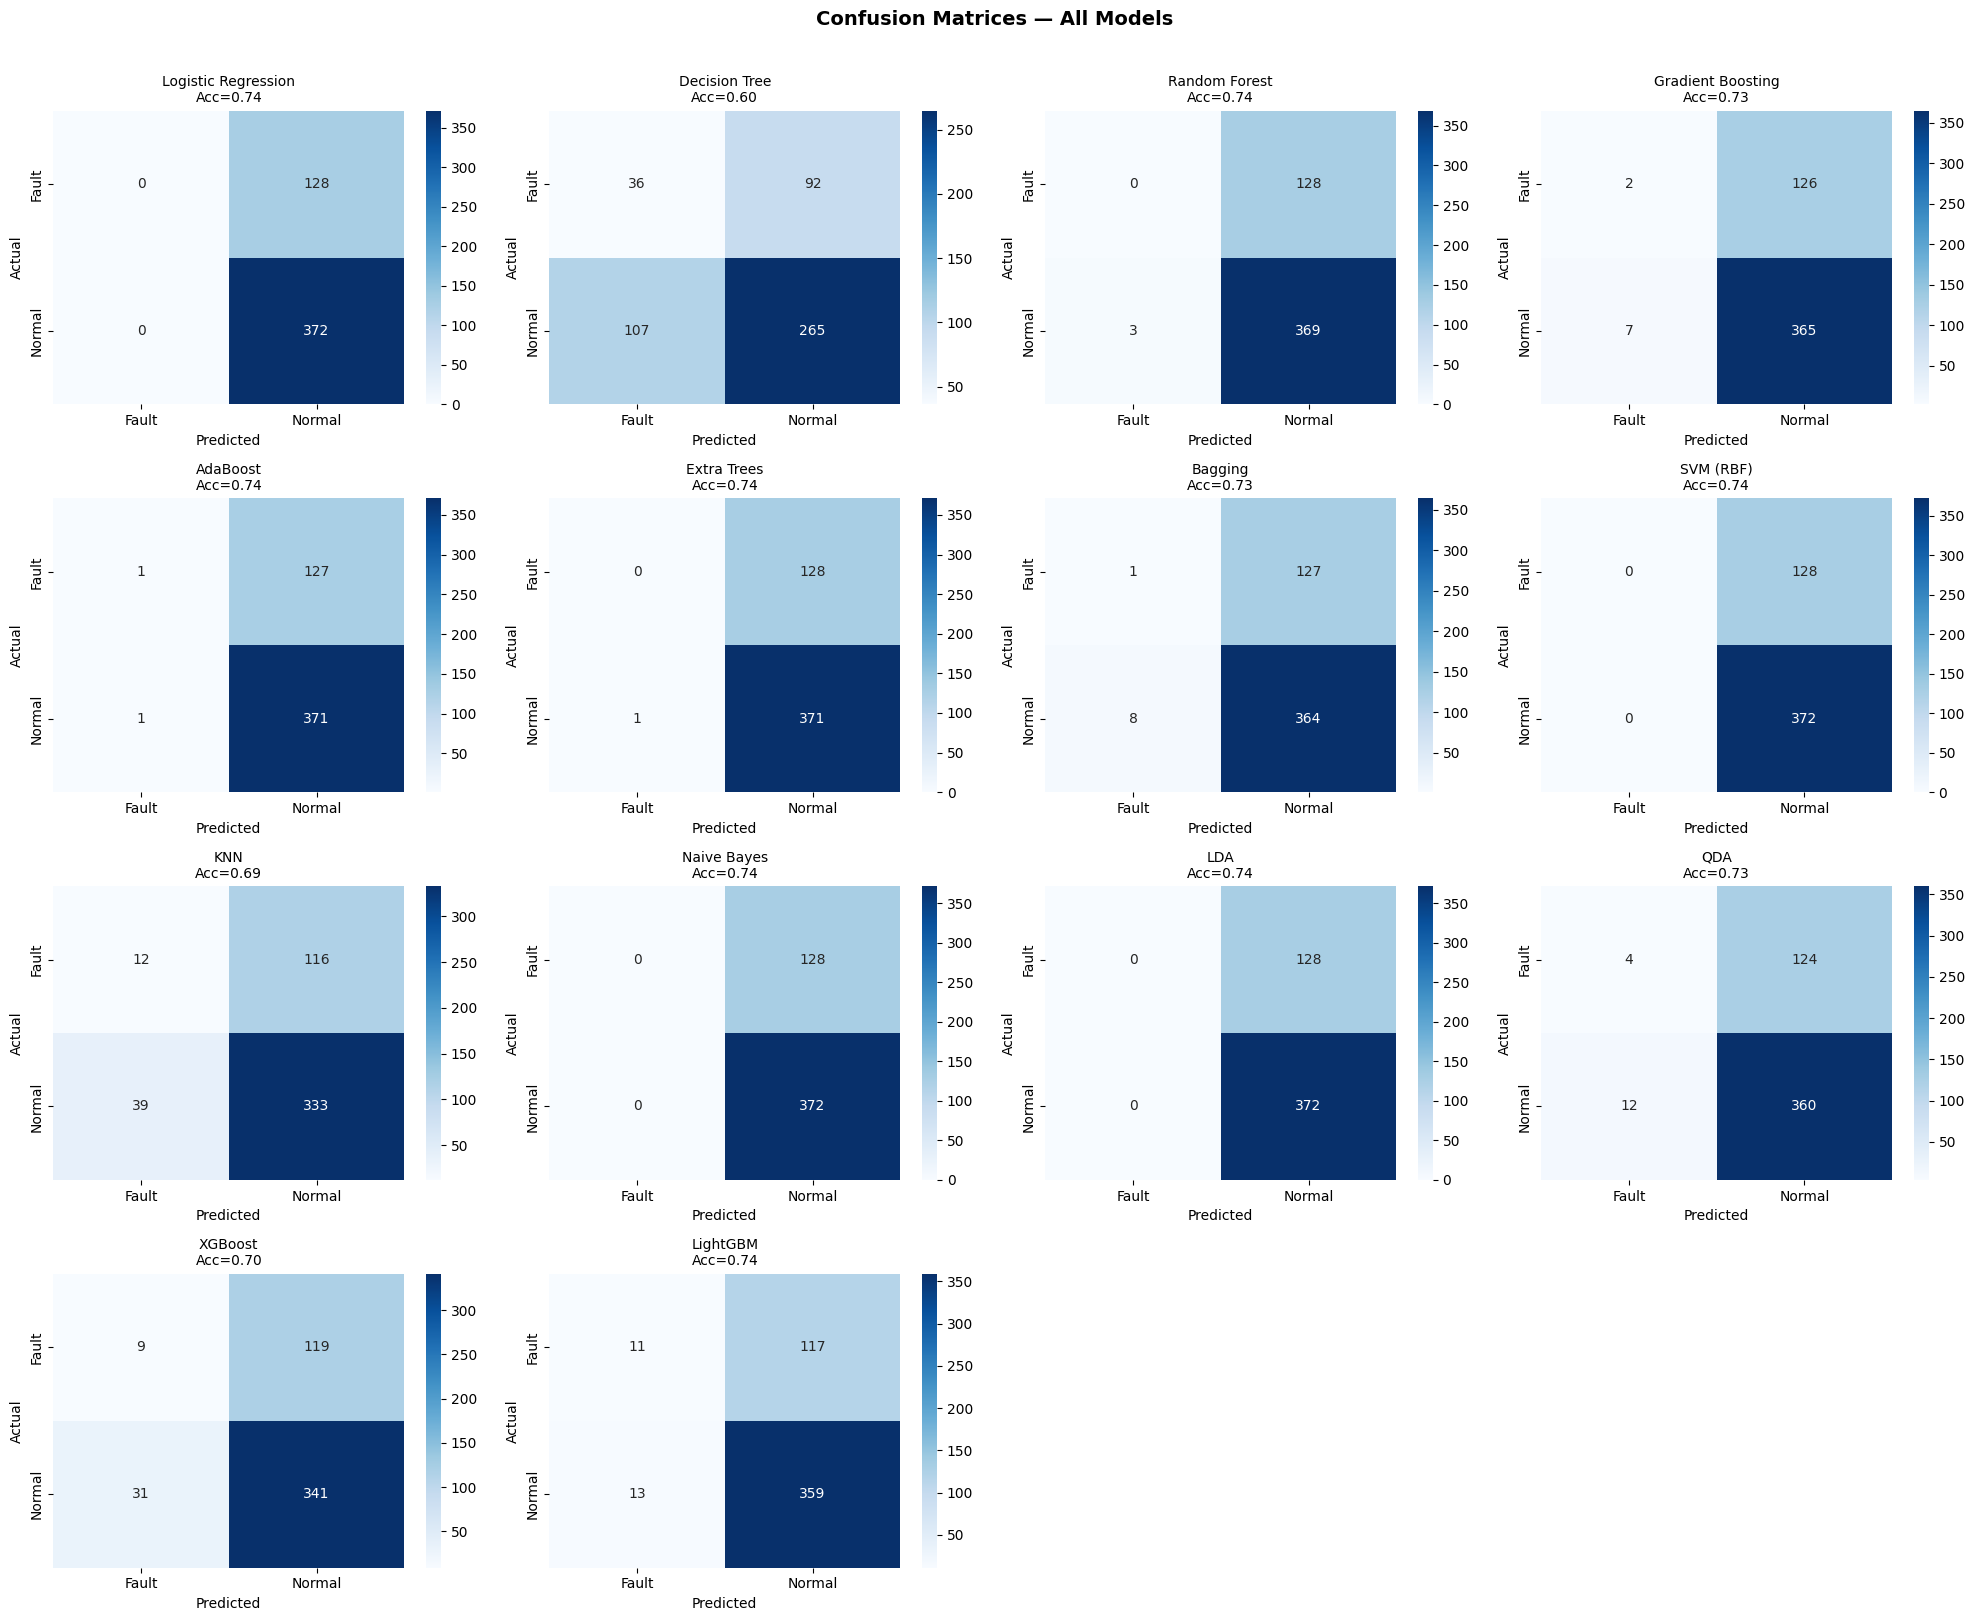

  → Saved: confusion_matrices.png


In [28]:
print("\n" + "=" * 70)
print("STEP 6: CONFUSION MATRICES")
print("=" * 70)
 
n_models = len(models)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()
 
for i, (name, metrics) in enumerate(model_metrics.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_)
    axes[i].set_title(f"{name}\nAcc={metrics['Accuracy']:.2f}", fontsize=10)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
 
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Saved: confusion_matrices.png")


STEP 7: ROC CURVES


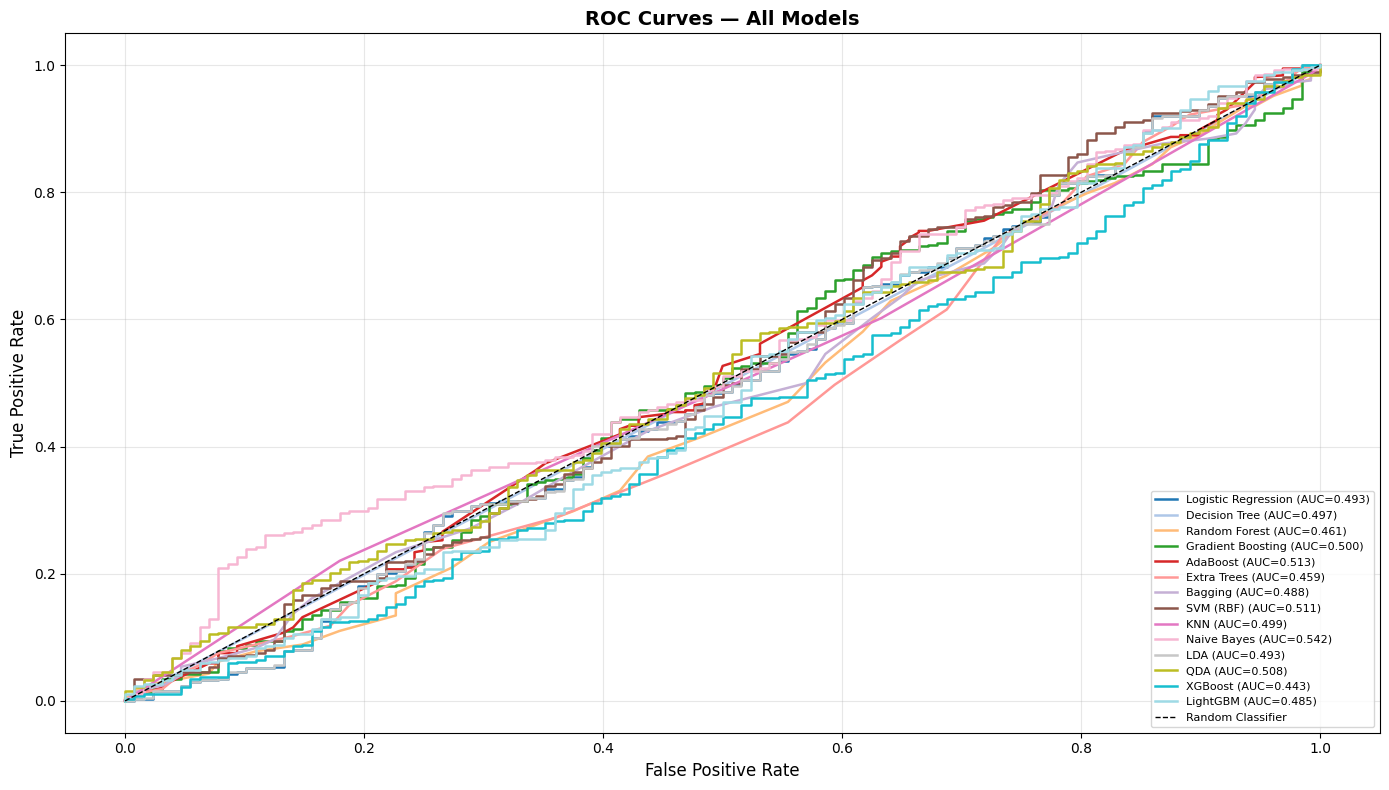

  → Saved: roc_curves.png


In [29]:
print("\n" + "=" * 70)
print("STEP 7: ROC CURVES")
print("=" * 70)
 
plt.figure(figsize=(14, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(models)))
 
for (name, metrics), color in zip(model_metrics.items(), colors):
    if metrics['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
        auc_val = metrics['ROC-AUC']
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", color=color, linewidth=1.8)
 
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Models", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Saved: roc_curves.png")


STEP 8: MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.744     0.7440  1.0000    0.8532   0.4934
          SVM (RBF)     0.744     0.7440  1.0000    0.8532   0.5106
        Naive Bayes     0.744     0.7440  1.0000    0.8532   0.5424
                LDA     0.744     0.7440  1.0000    0.8532   0.4931
           AdaBoost     0.744     0.7450  0.9973    0.8529   0.5131
        Extra Trees     0.742     0.7435  0.9973    0.8519   0.4594
      Random Forest     0.738     0.7425  0.9919    0.8493   0.4612
           LightGBM     0.740     0.7542  0.9651    0.8467   0.4854
  Gradient Boosting     0.734     0.7434  0.9812    0.8459   0.4995
            Bagging     0.730     0.7413  0.9785    0.8436   0.4884
                QDA     0.728     0.7438  0.9677    0.8411   0.5083
            XGBoost     0.700     0.7413  0.9167    0.8197   0.4434
                KNN     0.690     0.7416  0.8952    0.8112   0.4995
      Decisio

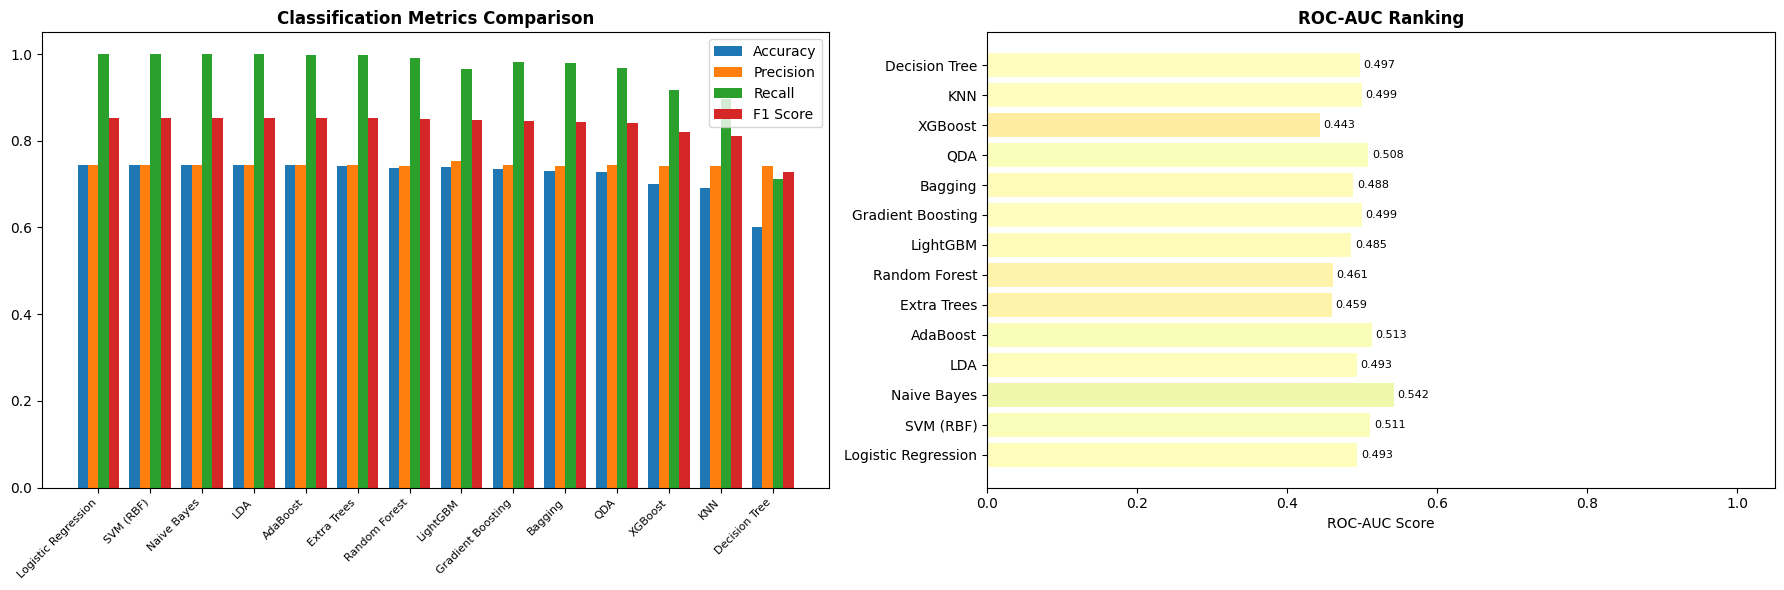

Saved: model_comparison.png


In [30]:
print("\n" + "=" * 70)
print("STEP 8: MODEL PERFORMANCE SUMMARY")
print("=" * 70)
 
summary_data = []
for name, m in model_metrics.items():
    summary_data.append({
        'Model'    : name,
        'Accuracy' : round(m['Accuracy'],  4),
        'Precision': round(m['Precision'], 4),
        'Recall'   : round(m['Recall'],    4),
        'F1 Score' : round(m['F1 Score'],  4),
        'ROC-AUC'  : round(m['ROC-AUC'],   4) if m['ROC-AUC'] else 'N/A'
    })
 
summary_df = pd.DataFrame(summary_data).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))
 
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(summary_df))
width = 0.2
 
for j, metric in enumerate(metrics_to_plot):
    vals = pd.to_numeric(summary_df[metric], errors='coerce')
    axes[0].bar(x + j * width, vals, width, label=metric)
 
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(summary_df['Model'], rotation=45, ha='right', fontsize=8)
axes[0].set_title("Classification Metrics Comparison", fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
 
# AUC bar
auc_vals = pd.to_numeric(summary_df['ROC-AUC'], errors='coerce')
bars = axes[1].barh(summary_df['Model'], auc_vals, color=plt.cm.RdYlGn(auc_vals))
axes[1].set_xlabel("ROC-AUC Score")
axes[1].set_title("ROC-AUC Ranking", fontweight='bold')
axes[1].set_xlim(0, 1.05)
 
for bar, val in zip(bars, auc_vals):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va='center', fontsize=8)
 
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

In [31]:
print("\n" + "=" * 70)
print(f"STEP 9: DETAILED REPORT — {best_model_name}")
print("=" * 70)
print(classification_report(
    y_test,
    model_metrics[best_model_name]['y_pred'],
    target_names=le_target.classes_
))


STEP 9: DETAILED REPORT — Logistic Regression
              precision    recall  f1-score   support

       Fault       0.00      0.00      0.00       128
      Normal       0.74      1.00      0.85       372

    accuracy                           0.74       500
   macro avg       0.37      0.50      0.43       500
weighted avg       0.55      0.74      0.63       500




STEP 10: FEATURE IMPORTANCE — Random Forest


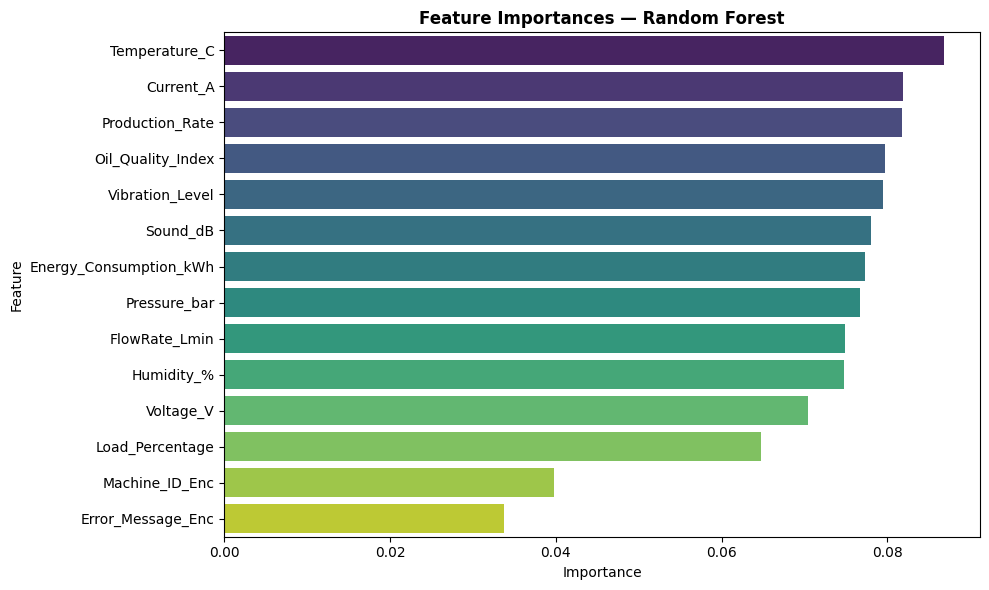

               Feature  Importance
         Temperature_C    0.086830
             Current_A    0.081934
       Production_Rate    0.081768
     Oil_Quality_Index    0.079738
       Vibration_Level    0.079465
              Sound_dB    0.078005
Energy_Consumption_kWh    0.077295
          Pressure_bar    0.076686
         FlowRate_Lmin    0.074822
            Humidity_%    0.074736
             Voltage_V    0.070400
       Load_Percentage    0.064768
        Machine_ID_Enc    0.039787
     Error_Message_Enc    0.033766
  → Saved: feature_importance.png

✅ PIPELINE COMPLETE!
   Best Model : Logistic Regression
   Accuracy   : 0.744
   F1 Score   : 0.8532
   ROC-AUC    : 0.4934


In [32]:
if 'Random Forest' in trained_models:
    print("\n" + "=" * 70)
    print("STEP 10: FEATURE IMPORTANCE — Random Forest")
    print("=" * 70)
 
    rf_model = trained_models['Random Forest']
    importances = rf_model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    fi_df.sort_values('Importance', ascending=False, inplace=True)
 
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
    plt.title("Feature Importances — Random Forest", fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
 
    print(fi_df.to_string(index=False))
    print("  → Saved: feature_importance.png")
 
print("\n" + "=" * 70)
print("✅ PIPELINE COMPLETE!")
print(f"   Best Model : {best_model_name}")
best_row = summary_df[summary_df['Model'] == best_model_name].iloc[0]
print(f"   Accuracy   : {best_row['Accuracy']}")
print(f"   F1 Score   : {best_row['F1 Score']}")
print(f"   ROC-AUC    : {best_row['ROC-AUC']}")
print("=" * 70)